<a href="https://colab.research.google.com/github/yse-eds-cert/yse-eds-cert-classroom-code-along-notebooks-code_along_notebooks/blob/main/course-1-data-foundations/module_3/C1M3L5_bsc-dscrptve-stats-pt-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Example: Data on measurements of 40,000+ trees between 1888 and 1974. Measurements include
    TreeID	
    TreeSpecies 	Species name 	
    NFI_mainspecies 	NFI main species 	
    TreeAge 	age	
    DBH 	Mean DBH [mm] 	
    H_total 	Total height [dm] 	
    Lat* 	Latitude of the plot centre 	
    Long* 	Longitude of the plot centre 	
    Elev* 	Elevation [meter above sea level] 	
    NFI_PR 	NFI Production region15 	Jura, Plateau, Pre-Alps, Alps 
    InvYear 	Inventory year 	
    StandAge 	Age structure (even-aged, uneven-aged)
    StandComp 	Tree species composition 	
        - pure 
        - conifer mixed (> 75% conifers) 
        - broadleaved mixed (> 75% broadleaves) 
        - conifer-broadleaved mixed 

In [3]:
#Get partial dataset
swiss_Trees <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/Swiss_Forest_Inventory_Reduced.csv")
dim(swiss_Trees)

[1] 40349    13

In [2]:
#Get variable names
names(swiss_Trees)

[1] "SiteID"          "Lat"             "Long"            "Elevation"      
 [5] "NFI_PR"          "InvYear"         "StandAge"        "StandComp"      
 [9] "TreeSpecies"     "NFI_mainspecies" "TreeAge"         "DBH"            
[13] "H_total"

In [3]:
#Get age range of measurement years as an example 
range(swiss_Trees$InvYear)

[1] 1888 1974

In [4]:
#table of Stand Composition
table(swiss_Trees$StandComp)


        broadleaved mixed conifer-broadleaved mixed             conifer mixed 
                      620                      5490                      8758 
                     pure 
                    23685 

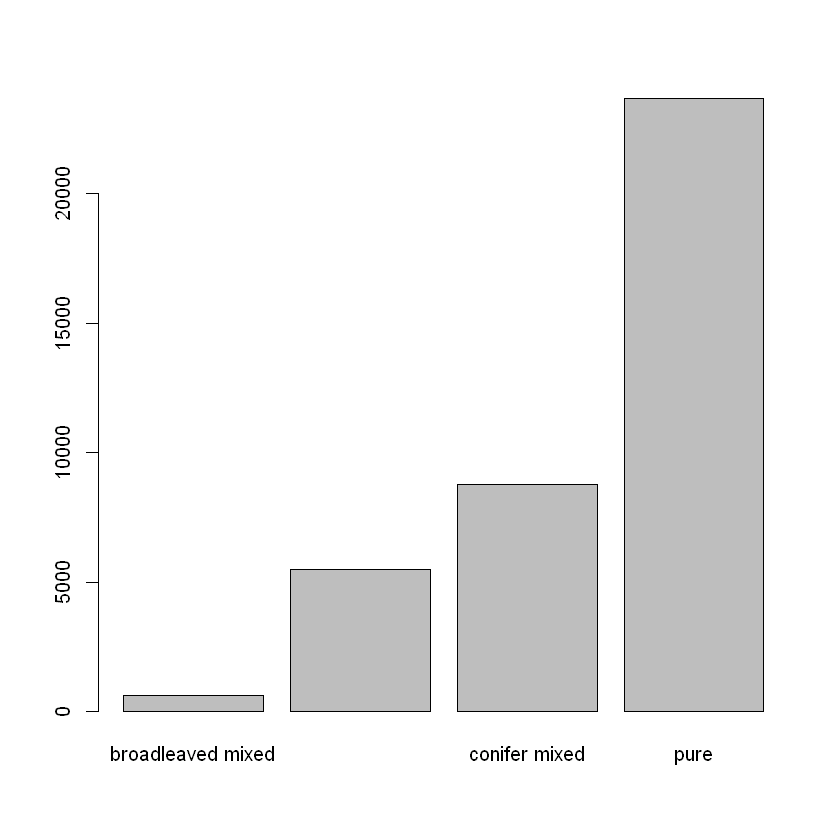

In [5]:
#bar chart of stand composition
barplot(table(swiss_Trees$StandComp))

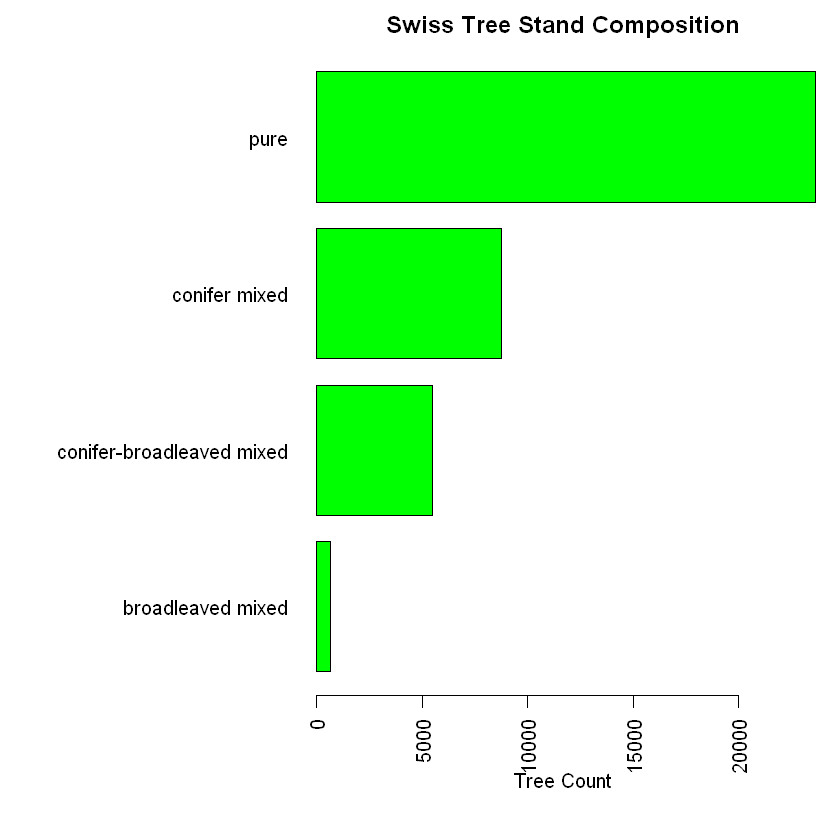

In [6]:
#lets make this look nicer
par(mar = c(6, 13, 2, 1))
barplot(table(swiss_Trees$StandComp), 
        col = 'green', 
        main = "Swiss Tree Stand Composition",
        horiz = T,
        las = 2,
        xlab = "Tree Count")

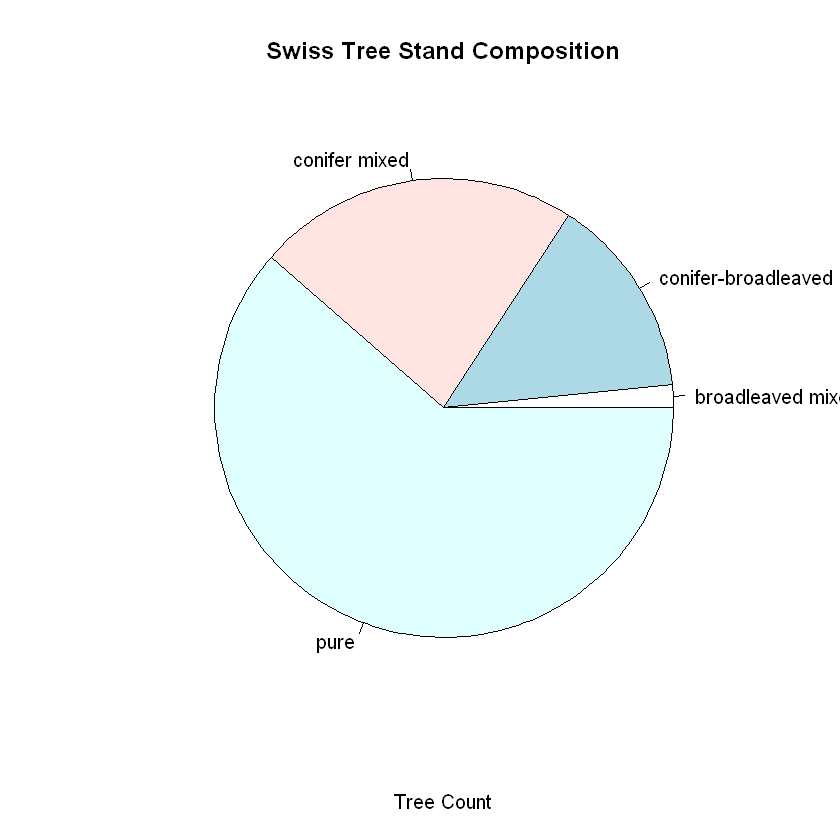

In [8]:
#pie chart of stand composition
pie(table(swiss_Trees$StandComp), 
        main = "Swiss Tree Stand Composition",
        las = 2,
        xlab = "Tree Count")

In [9]:
#Two-way contingency table of Stand Composition by NFI Production Region
#that is, counts for combinations of two categorical variables
table(swiss_Trees$StandComp, swiss_Trees$NFI_PR)

                           
                             Alps  Jura Plateau Pre-Alps
  broadleaved mixed           131    85     198      206
  conifer-broadleaved mixed    11  2488    2097      894
  conifer mixed               547   850    2622     4739
  pure                       2242  3403   11288     6752

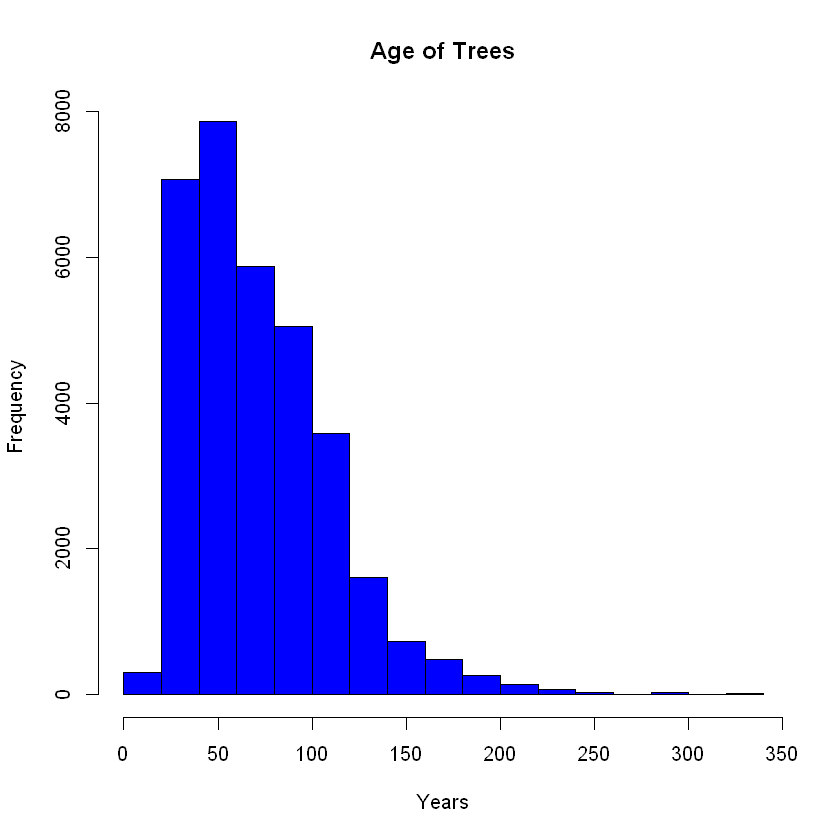

In [10]:
#Make a histogram of age of trees
hist(swiss_Trees$TreeAge,
     main = "Age of Trees",
     xlab = "Years",
     col = 'blue')

Crimean War Example - Florence Nightingale Data

In [11]:
#get the data
crimea <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/Crimean_War2.csv")
#see the first few rows
head(crimea)

,X,Wounds,Disease,Other
,<chr>,<int>,<int>,<int>
1,Apr_1854,0,1,5
2,May_1854,0,12,9
3,Jun_1854,0,11,6
4,Jul_1854,0,359,23
5,Aug_1854,1,828,30
6,Sep_1854,81,788,70


In [12]:
# Table -  a bit different than for most datasets
apply(crimea[, c(2:4)], 2, sum)

Wounds Disease   Other 
   1758   14476    1748

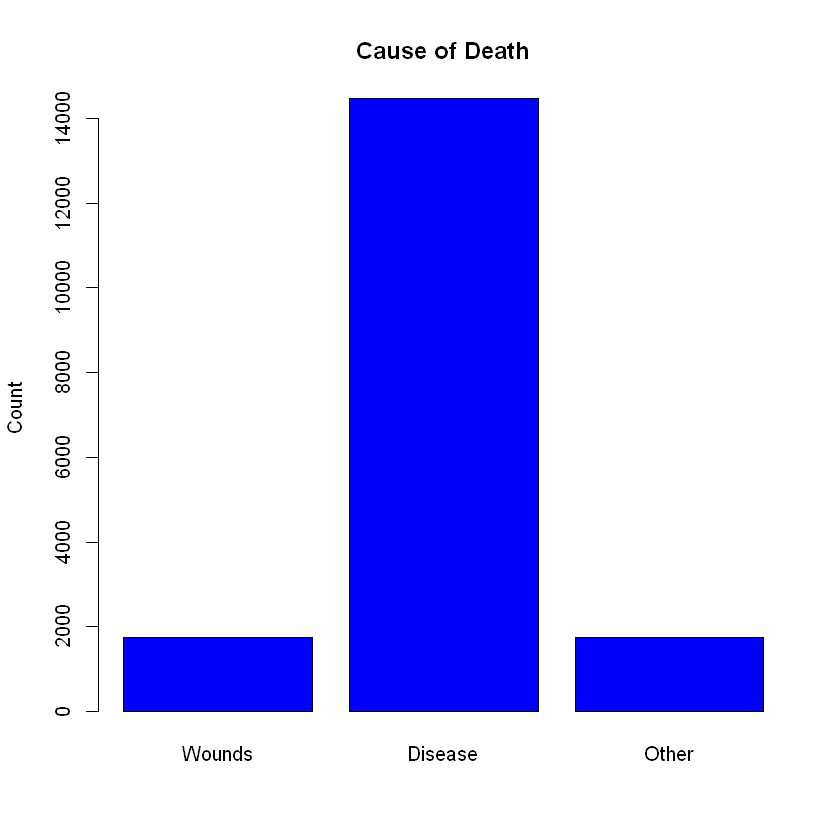

In [13]:
#Bar Chart for overall cause of death
barplot(apply(crimea[, c(2:4)], 2, sum), 
        main = "Cause of Death", 
        xlab = "", 
        ylab = "Count", col = 'blue')

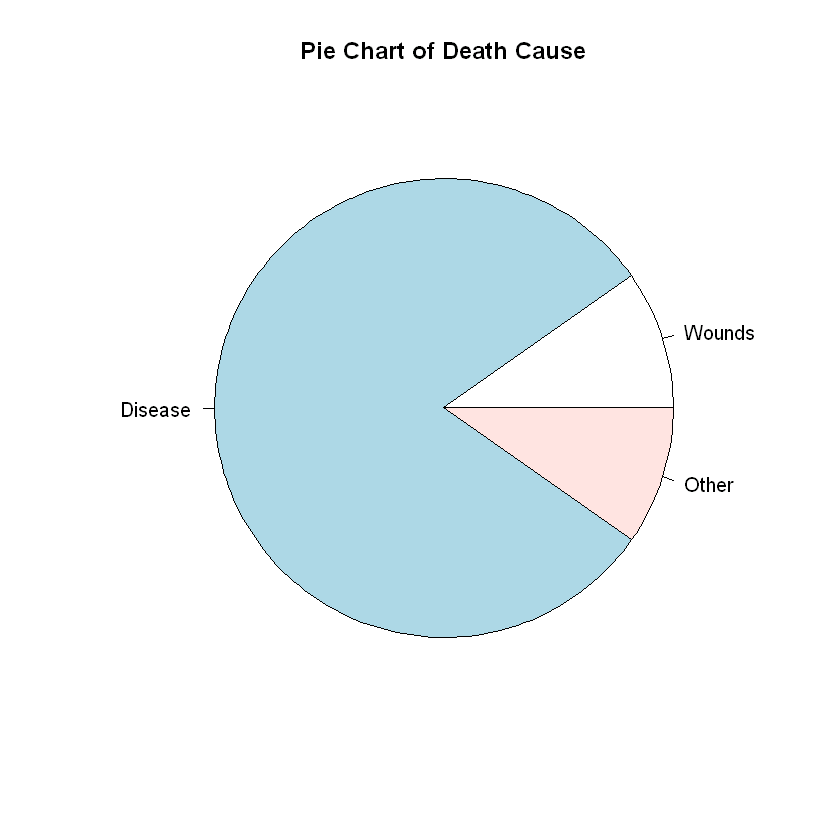

In [14]:
#Pie Chart
pie(apply(crimea[, c(2:4)], 2, sum), 
    labels = colnames(crimea[, c(2:4)]), 
    main = "Pie Chart of Death Cause")

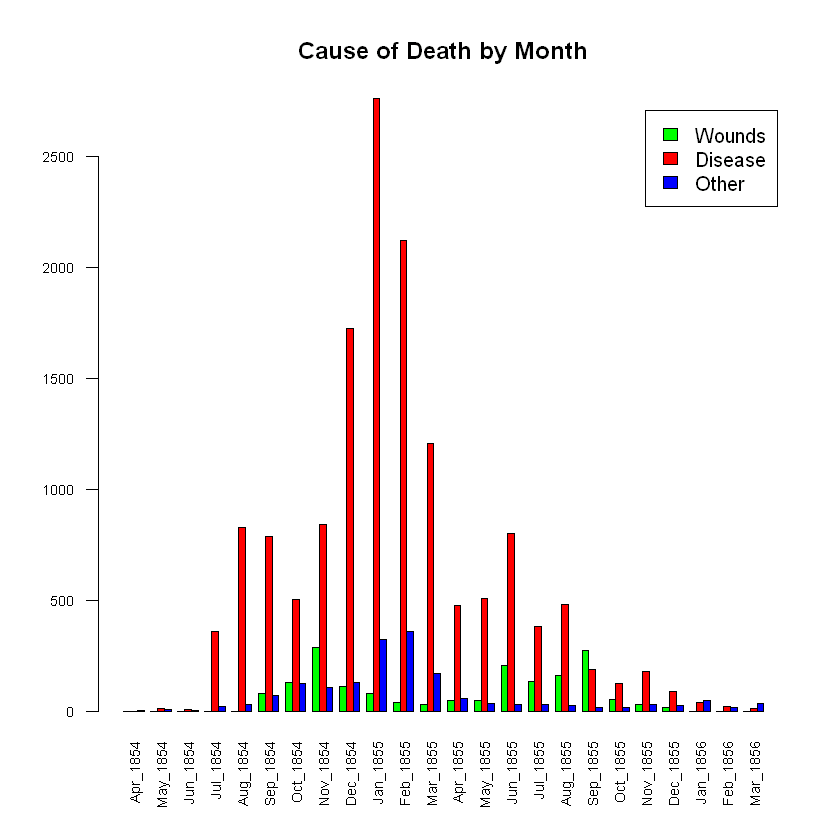

In [15]:
#Bar Chart by month and cause of death
barplot(t(crimea[, c(2:4)]), 
        xlab = "",
        names.arg = crimea[, 1],
        col = c("green", "red", "blue"), 
        legend = colnames(crimea[, c(2:4)]), 
        beside = TRUE, 
        las = 2, 
        cex.axis = .7, 
        cex.names = .7,
        main = "Cause of Death by Month")
mtext("Month/Year", side = 1, line = 6)

World Bank Data, 2024 Example

In [16]:
WB <- read.csv("https://raw.githubusercontent.com/jreuning/sds230_data/refs/heads/main/WB_2024.csv", header = T, as.is = T)

#We'll focus an a few variables
WB2 <- WB[, c("Country", "Rural", "GNI", "CO2", "EnergyUse", "LifeExp", "Renewable", "Measles")]

#Get subset of data that is complete for these variables  (note that column 1 is the country name)
WB2 <- WB2[complete.cases(WB2), ]
dim(WB2)
head(WB2)

[1] 178   8

,Country,Rural,GNI,CO2,EnergyUse,LifeExp,Renewable,Measles
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,Afghanistan,73.067,360,0.1380007,2.94,62.879,20.0,68
2,Albania,35.397,6770,1.6150836,2.27,76.833,41.9,86
3,Algeria,24.732,4490,3.9435787,5.61,77.129,0.1,79
6,Angola,31.312,1870,0.5671895,3.10,61.929,52.9,37
7,Antigua and Barbuda,75.668,18710,2.9617226,4.83,79.236,0.9,99
8,Argentina,7.537,11590,3.9804883,3.39,76.064,9.2,83


In [17]:
#First, lets see look at the steps of making a histogram
#Look at raw data
WB2$Renewable

[1] 20.0 41.9  0.1 52.9  0.9  9.2  9.1 12.3 36.0  1.3  1.1  0.0 25.0  5.5  8.2
 [16] 11.7 26.6 54.5 81.8 12.8 36.6 27.4 46.5  0.0 20.4 71.2 83.1 22.6 52.4 79.2
 [31] 23.8 90.9 69.9 24.2 15.2 29.7 41.2 96.3 71.4 34.2 58.2 34.1 15.6 17.2 39.5
 [46] 26.6  8.8 14.8 18.9  6.1 21.9  5.2 38.0 65.4 90.6 29.7 50.2 16.2 91.3 48.6
 [61] 25.2 17.6 39.0 21.5 10.2 62.1 66.8 87.4 13.2 76.7 45.9 15.3 82.4 34.9 20.2
 [76]  0.9  1.1 12.7  6.2 17.5 10.5  8.8 11.5  2.0 67.7 42.2  3.6  0.1 27.6 51.5
 [91] 44.0  6.8 33.6 93.2  3.1 33.2 20.5 83.6 71.1  7.5  1.4 71.2  8.6 12.1 22.1
[106]  8.6 13.0  2.1 21.4  3.0 10.9 76.9 62.9 30.0  1.6 73.7 12.2 28.9 50.4 79.6
[121] 80.3 19.5 61.4  0.1 41.6 28.0 54.5 58.8 30.6 28.0 15.2 32.3  0.0 23.6  3.5
[136] 79.4 36.0 40.8  0.1 35.4  1.7 71.1  1.1 17.9 23.4 49.1 95.4  9.7 19.0 48.8
[151]  1.6  9.7  5.0 61.0 14.5 57.9 27.7 34.9 78.3 19.0 12.1 75.1  1.8  0.5 11.6
[166] 12.0  5.0 91.0  8.9  1.0 12.2 10.9 57.8  1.0 24.6 24.2 83.0 82.4

In [18]:
#Next we look at sorted data
sort(WB2$Renewable)

[1]  0.0  0.0  0.0  0.1  0.1  0.1  0.1  0.5  0.9  0.9  1.0  1.0  1.1  1.1  1.1
 [16]  1.3  1.4  1.6  1.6  1.7  1.8  2.0  2.1  3.0  3.1  3.5  3.6  5.0  5.0  5.2
 [31]  5.5  6.1  6.2  6.8  7.5  8.2  8.6  8.6  8.8  8.8  8.9  9.1  9.2  9.7  9.7
 [46] 10.2 10.5 10.9 10.9 11.5 11.6 11.7 12.0 12.1 12.1 12.2 12.2 12.3 12.7 12.8
 [61] 13.0 13.2 14.5 14.8 15.2 15.2 15.3 15.6 16.2 17.2 17.5 17.6 17.9 18.9 19.0
 [76] 19.0 19.5 20.0 20.2 20.4 20.5 21.4 21.5 21.9 22.1 22.6 23.4 23.6 23.8 24.2
 [91] 24.2 24.6 25.0 25.2 26.6 26.6 27.4 27.6 27.7 28.0 28.0 28.9 29.7 29.7 30.0
[106] 30.6 32.3 33.2 33.6 34.1 34.2 34.9 34.9 35.4 36.0 36.0 36.6 38.0 39.0 39.5
[121] 40.8 41.2 41.6 41.9 42.2 44.0 45.9 46.5 48.6 48.8 49.1 50.2 50.4 51.5 52.4
[136] 52.9 54.5 54.5 57.8 57.9 58.2 58.8 61.0 61.4 62.1 62.9 65.4 66.8 67.7 69.9
[151] 71.1 71.1 71.2 71.2 71.4 73.7 75.1 76.7 76.9 78.3 79.2 79.4 79.6 80.3 81.8
[166] 82.4 82.4 83.0 83.1 83.6 87.4 90.6 90.9 91.0 91.3 93.2 95.4 96.3

[1]   0  10  20  30  40  50  60  70  80  90 100

[1] 67 38 29 18 11 12  8 13  9  7

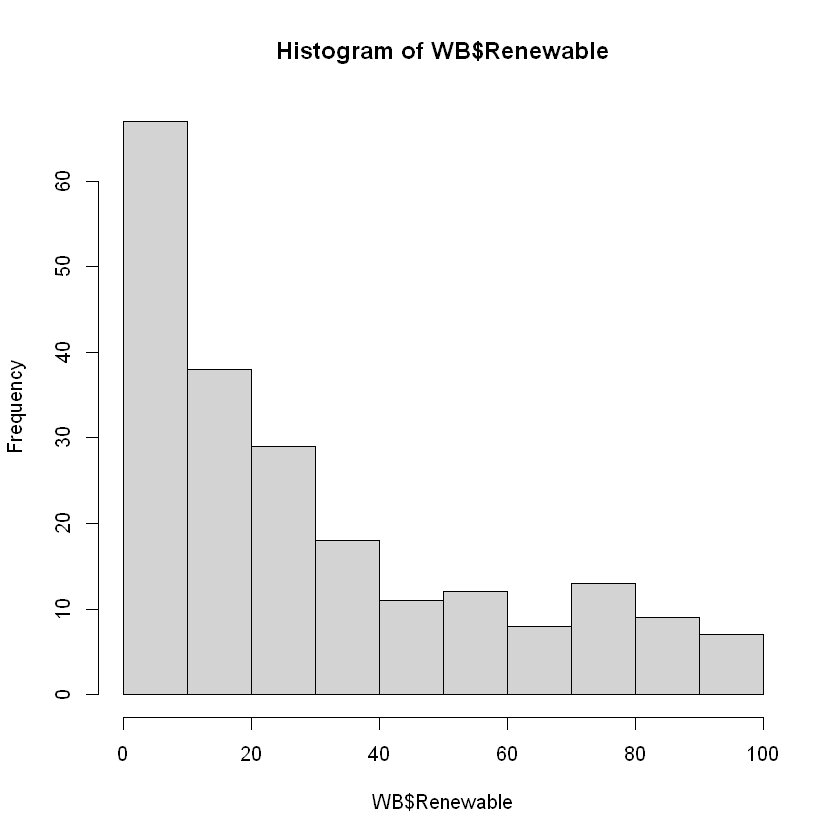

In [19]:
#to see how a histogram is made, we actually make one, save it to an object and then look at what was saved
hist2 <- hist(WB$Renewable)
hist2$breaks
hist2$counts

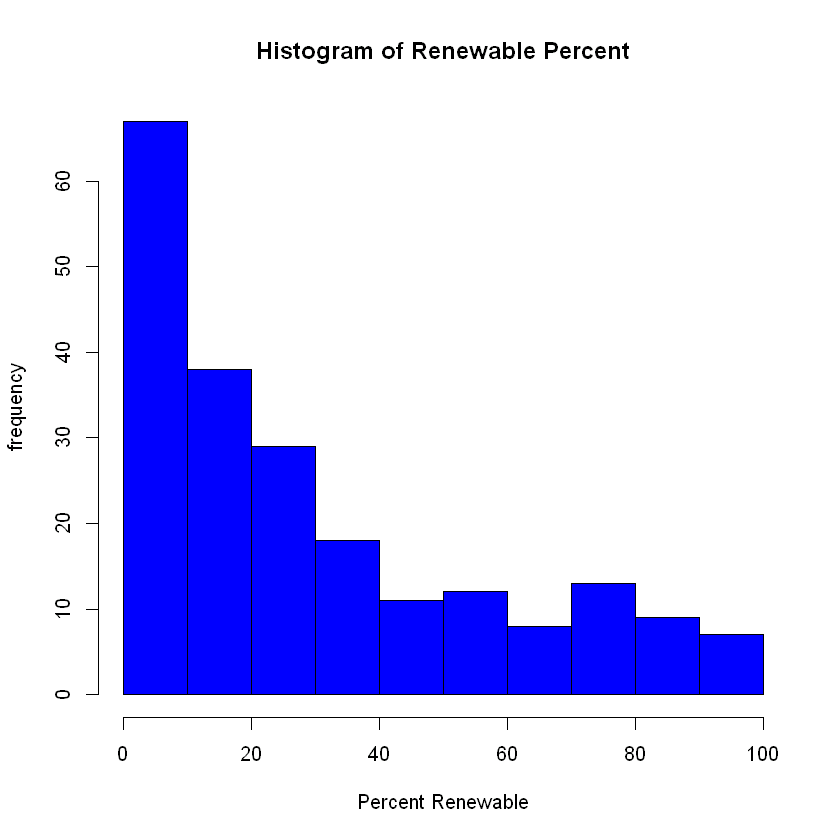

In [20]:
#Lets make a nice histogram now
hist(WB$Renewable, 
     col = "blue", 
     main = "Histogram of Renewable Percent", 
     xlab = "Percent Renewable", 
     ylab = "frequency")

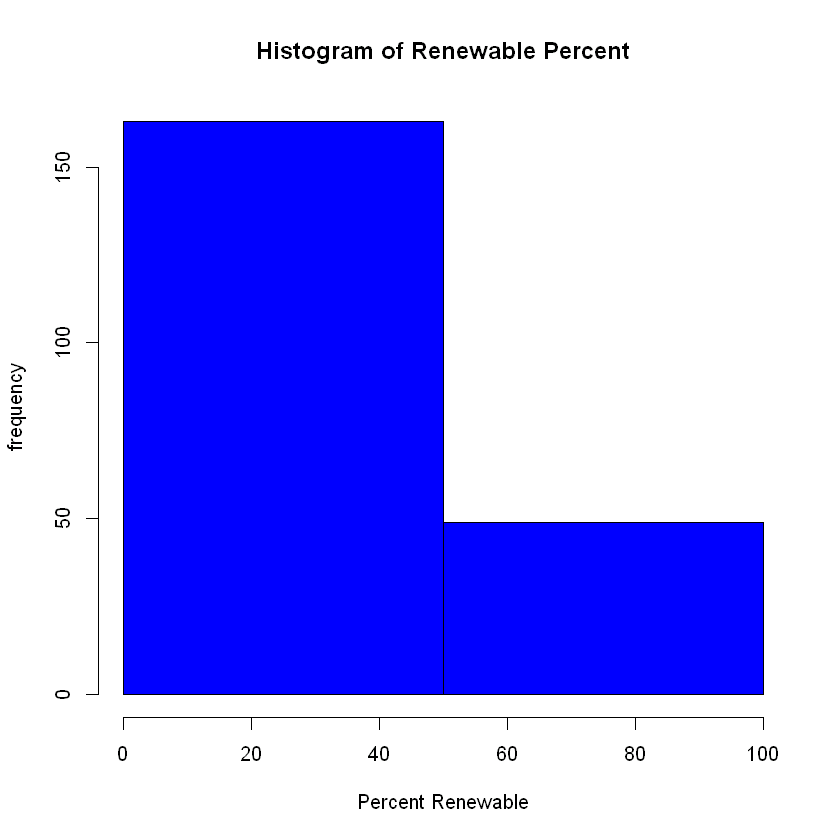

In [22]:
#A histogram with too many breaks
hist(WB$Renewable, 
     col = "blue", 
     main = "Histogram of Renewable Percent", 
     xlab = "Percent Renewable", 
     ylab = "frequency", 
     breaks = 2)

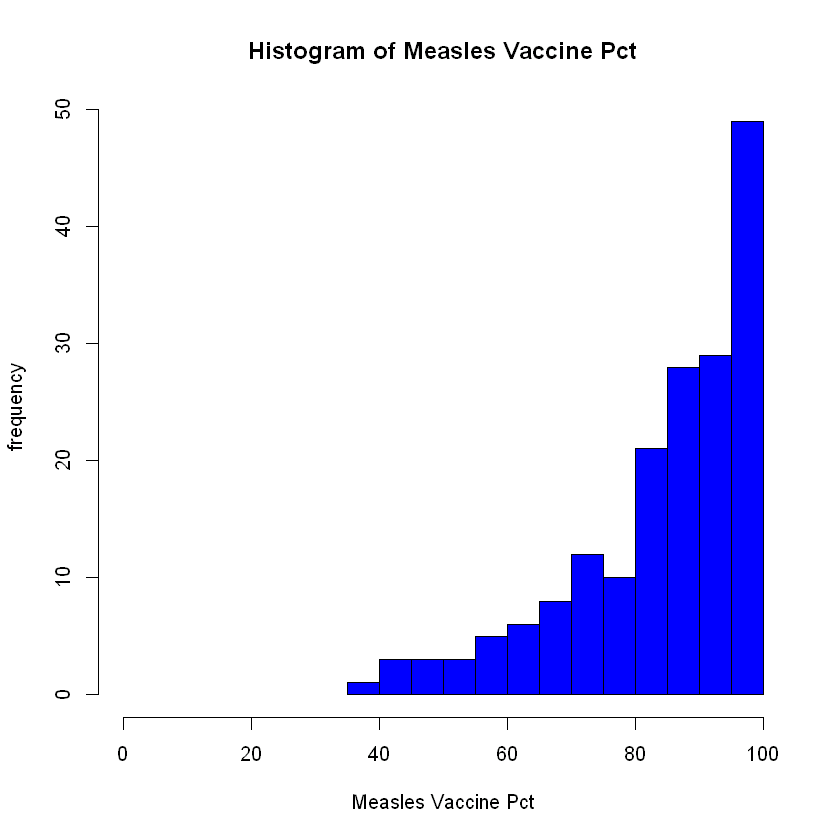

In [23]:
#Make a histogram of the Measles vaccination rates:
hist(WB2$Measles, 
     col = "blue", 
     main = "Histogram of Measles Vaccine Pct", 
     xlim = c(0, 100), 
     xlab = "Measles Vaccine Pct", 
     ylab = "frequency")

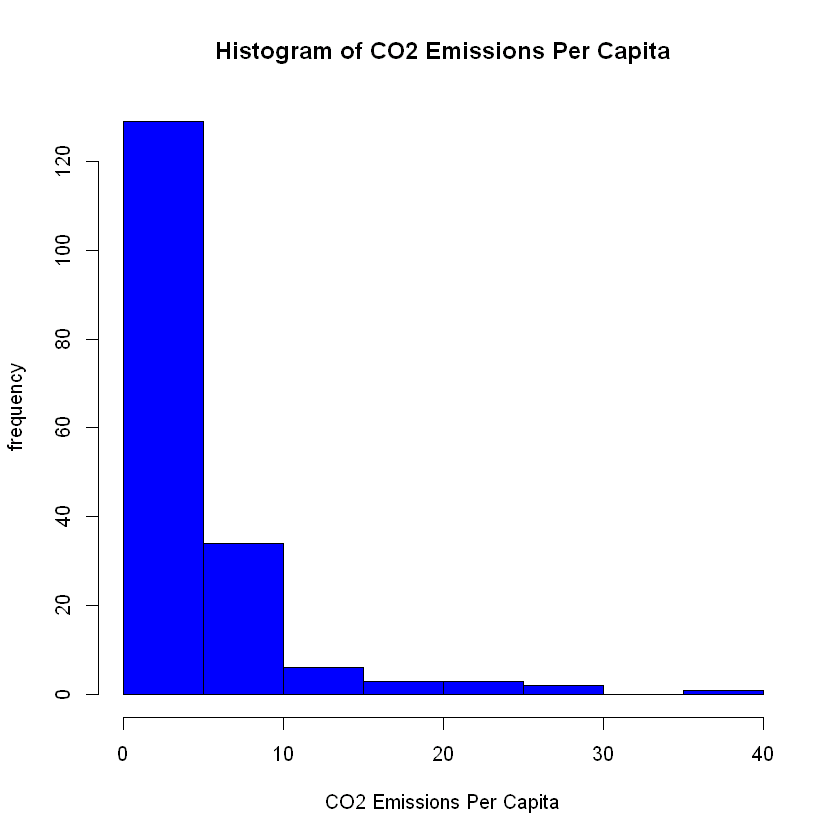

In [24]:
#Make a histogram of the  CO2 emissions per capita :
hist(WB2$CO2, 
     col = "blue", 
     main = "Histogram of CO2 Emissions Per Capita", 
     xlab = "CO2 Emissions Per Capita", 
     ylab = "frequency")